> [返回仓库首页](../README.md) · [查看可视化学习路线](../docs/learning-roadmap.md)

建议按路线图顺序学习本章。探索性 PCA/KMeans 仅用于可视化；严格预测结果应使用训练集拟合的转换器和独立测试集。

# 13 综合项目：一朵鸢尾花跑通机器学习全流程（16 个模型大横评）

**本章目标**：把 01–12 章学过的所有模型放进**同一个项目、同一份数据、同一套评估标准**，
完整跑通「探索 → 特征工程 → 建模横评 → 结论」的标准流程，作为之后任何真实项目
（包括量化 + ML）的通用样板。

> 本章是工程流程章：**所有模型直接调用** sklearn / XGBoost 的成熟接口，
> 不做任何数学推导与手写实现。数据来自 GitHub（seaborn 官方数据仓库），
> 已保存本地副本，选择包含 NumPy、Matplotlib、pandas、scikit-learn、XGBoost
> 的内核后可直接 Run All。

项目一句话：**给我一朵花的 4 个尺寸，猜它是三个品种中的哪一个**（分类主任务）；
顺带用 3 个尺寸**预测花瓣宽度数值**（回归副任务），让线性回归也自然登场。


## 模型简介与学习参考

本章覆盖 01–12 章的全部模型家族，共 **16 个模型**，按"在流程中的角色"分三组：

| 环节 | 模型 | 在本项目中的角色 |
|---|---|---|
| 无监督探索（3） | PCA、核 PCA、KMeans | 先不告诉模型品种，让它自己看数据怎么分 |
| 分类主任务（9） | 逻辑回归、朴素贝叶斯、KNN、决策树、SVM(线性核)、SVM(RBF核)、随机森林、GBDT、XGBoost | 同一问题"4 尺寸 → 品种"，同一尺度横评 |
| 回归副任务（4） | 线性回归、KNN 回归、决策树回归、随机森林回归 | 同一问题"3 尺寸 → 花瓣宽度数值"，同一尺度横评 |

**学习参考**（权威文档，均为现成接口）：

- [scikit-learn 官方文档](https://scikit-learn.org/stable/)：逻辑回归、朴素贝叶斯、KNN、SVM、决策树、随机森林、GBDT、PCA、核 PCA、KMeans；
- [XGBoost 官方文档](https://xgboost.readthedocs.io/)：XGBClassifier；
- [seaborn 官方数据仓库](https://github.com/mwaskom/seaborn-data)：iris.csv 的来源（GitHub）。

本章按照 **数据 → 探索 → 特征工程 → 分类横评 → 回归横评 → 总结** 展开。


## 目录

- [1. 数据：GitHub 来源与读取](#data)
- [2. 探索性分析：让模型自己看数据](#eda)
  - [2.1 尺寸分布](#dist)
  - [2.2 特征相关性](#corr)
  - [2.3 PCA：线性降维](#pca)
  - [2.4 核 PCA：非线性降维](#kpca)
  - [2.5 KMeans：无监督聚类](#kmeans)
- [3. 特征工程](#feat)
- [4. 分类主任务：9 个模型横评](#classify)
  - [4.1 模型清单与评估协议](#clf-models)
  - [4.2 交叉验证横评](#clf-cv)
  - [4.3 横评可视化](#clf-viz)
  - [4.4 独立测试集与混淆矩阵](#clf-test)
  - [4.5 ROC 曲线](#clf-roc)
  - [4.6 决策边界全景](#clf-boundary)
  - [4.7 特征重要性](#clf-importance)
- [5. 回归副任务：预测花瓣宽度](#regress)
- [6. 总结与验证](#summary)


<a id="data"></a>
## 1. 数据：GitHub 来源与读取

数据来自 **GitHub 上 seaborn 官方数据仓库**（[mwaskom/seaborn-data](https://github.com/mwaskom/seaborn-data)）
的 `iris.csv`：150 朵鸢尾花，每朵记录 4 个尺寸（花萼长/宽、花瓣长/宽），
真实品种 3 类（setosa / versicolor / virginica）。

本 notebook 已将数据保存为本地副本 `data/iris.csv`：优先读本地（离线可复现），
本地缺失时才从 GitHub 下载。


In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

DATA_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
DATA_PATH = Path("data/iris.csv")

if DATA_PATH.exists():
    iris = pd.read_csv(DATA_PATH)
    source_note = f"本地副本 {DATA_PATH}（GitHub: mwaskom/seaborn-data 的 iris.csv）"
else:
    iris = pd.read_csv(DATA_URL)
    DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
    iris.to_csv(DATA_PATH, index=False)
    source_note = f"已从 GitHub 下载并保存到 {DATA_PATH}"

SPECIES_CN = {
    "setosa": "山鸢尾",
    "versicolor": "变色鸢尾",
    "virginica": "维吉尼亚鸢尾",
}
ORDER = ["setosa", "versicolor", "virginica"]
iris["species_cn"] = iris["species"].map(SPECIES_CN)

print("数据来源:", source_note)
print("数据形状:", iris.shape, "（150 朵花，5 个原始列 + 1 个中文品种列）")
print()
print(iris.head().to_string(index=False))
print()
print("缺失值:", int(iris.isna().sum().sum()))
print("重复行:", int(iris.duplicated().sum()))
print()
print("品种分布:")
print(iris["species"].value_counts().to_string())


数据来源: 本地副本 data\iris.csv（GitHub: mwaskom/seaborn-data 的 iris.csv）
数据形状: (150, 6) （150 朵花，5 个原始列 + 1 个中文品种列）

 sepal_length  sepal_width  petal_length  petal_width species species_cn
          5.1          3.5           1.4          0.2  setosa        山鸢尾
          4.9          3.0           1.4          0.2  setosa        山鸢尾
          4.7          3.2           1.3          0.2  setosa        山鸢尾
          4.6          3.1           1.5          0.2  setosa        山鸢尾
          5.0          3.6           1.4          0.2  setosa        山鸢尾

缺失值: 0
重复行: 1

品种分布:
species
setosa        50
versicolor    50
virginica     50


### 1.2 统一绘图风格

全书风格统一：微软雅黑中文字体、同一套三色配色（一种品种一个颜色）、
统一高清导出。下面的 HTML 表格函数用于输出带样式的指标表。


In [2]:
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")

import matplotlib.pyplot as plt
from IPython.display import HTML, display

plt.rcParams.update({
    "font.sans-serif": ["Microsoft YaHei", "SimHei"],
    "axes.unicode_minus": False,
    "figure.dpi": 110,
    "savefig.dpi": 160,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

PALETTE = {
    "setosa": "#4C78A8",
    "versicolor": "#F58518",
    "virginica": "#54A24B",
}
THEME_BLUE = "#4C78A8"
THEME_RED = "#E45756"


def display_result_table(title, headers, rows, hidden_comment=""):
    header_html = "".join(
        f'<th style="padding:8px 12px;text-align:left;background:#eef3ff">{header}</th>'
        for header in headers
    )
    row_html = "".join(
        "<tr>" + "".join(
            f'<td style="padding:7px 12px;border-top:1px solid #dde3ee">{value}</td>'
            for value in row
        ) + "</tr>"
        for row in rows
    )
    comment_html = f"<!-- {hidden_comment} -->" if hidden_comment else ""
    display(HTML(
        f'<div style="max-width:820px"><h4>{title}</h4>'
        f'<table style="border-collapse:collapse;width:100%;font-size:14px">'
        f'<thead><tr>{header_html}</tr></thead><tbody>{row_html}</tbody></table>'
        f'{comment_html}</div>'
    ))


<a id="eda"></a>
## 2. 探索性分析：让模型自己看数据

EDA 阶段不是只画几张统计图，而是让**无监督模型先上岗**：
PCA / 核 PCA 回答"哪些维度最能把三类花分开"，KMeans 回答
"不给标签，机器自己能不能发现三类花"。它们的产出（主成分、聚类标签）
本身就是后续建模的"特征灵感"。


<a id="dist"></a>
### 2.1 尺寸分布

先看四个尺寸在三个品种下的分布：花萼尺寸有重叠，花瓣尺寸几乎能直接区分品种。


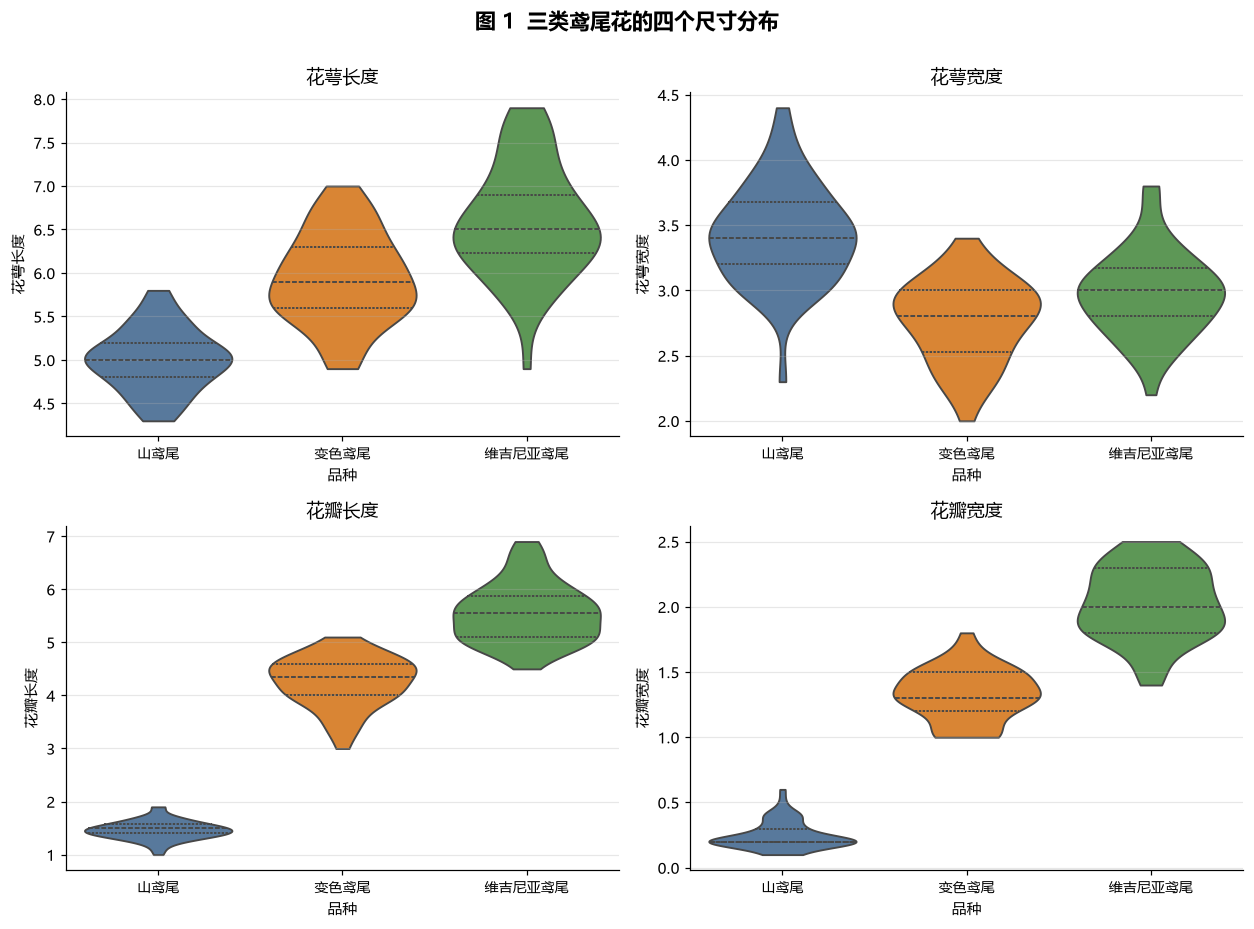

In [3]:
import seaborn as sns

FEAT_CN = {
    "sepal_length": "花萼长度",
    "sepal_width": "花萼宽度",
    "petal_length": "花瓣长度",
    "petal_width": "花瓣宽度",
}

fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.4))
for ax, (col, cn) in zip(axes.ravel(), FEAT_CN.items()):
    sns.violinplot(
        data=iris, x="species", y=col, hue="species", order=ORDER,
        palette=PALETTE, inner="quart", density_norm="width", cut=0,
        legend=False, ax=ax,
    )
    ax.set_title(cn)
    ax.set_xlabel("品种")
    ax.set_ylabel(cn)
    ax.set_xticks(range(len(ORDER)))
    ax.set_xticklabels([SPECIES_CN[s] for s in ORDER], fontsize=9)
fig.suptitle("图 1  三类鸢尾花的四个尺寸分布", y=1.0, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


<a id="corr"></a>
### 2.2 特征相关性

花瓣长度与花瓣宽度高度相关（相关系数接近 0.96）；花萼宽度与其他特征基本不相关。


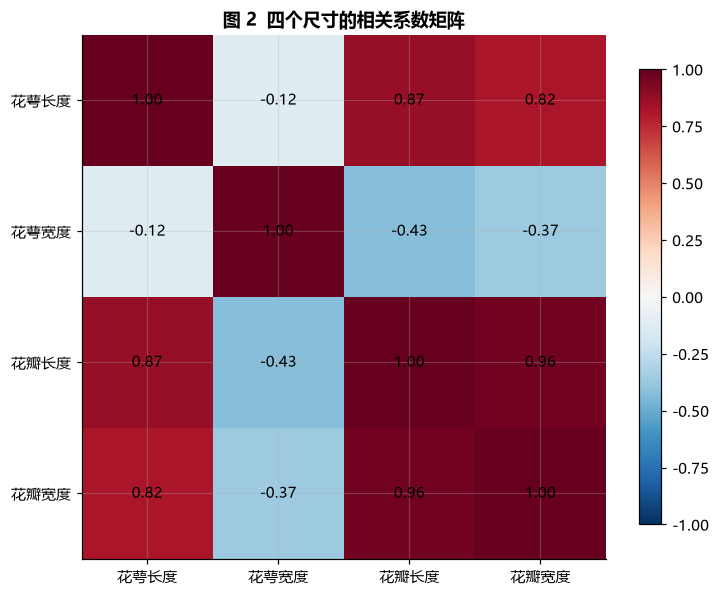

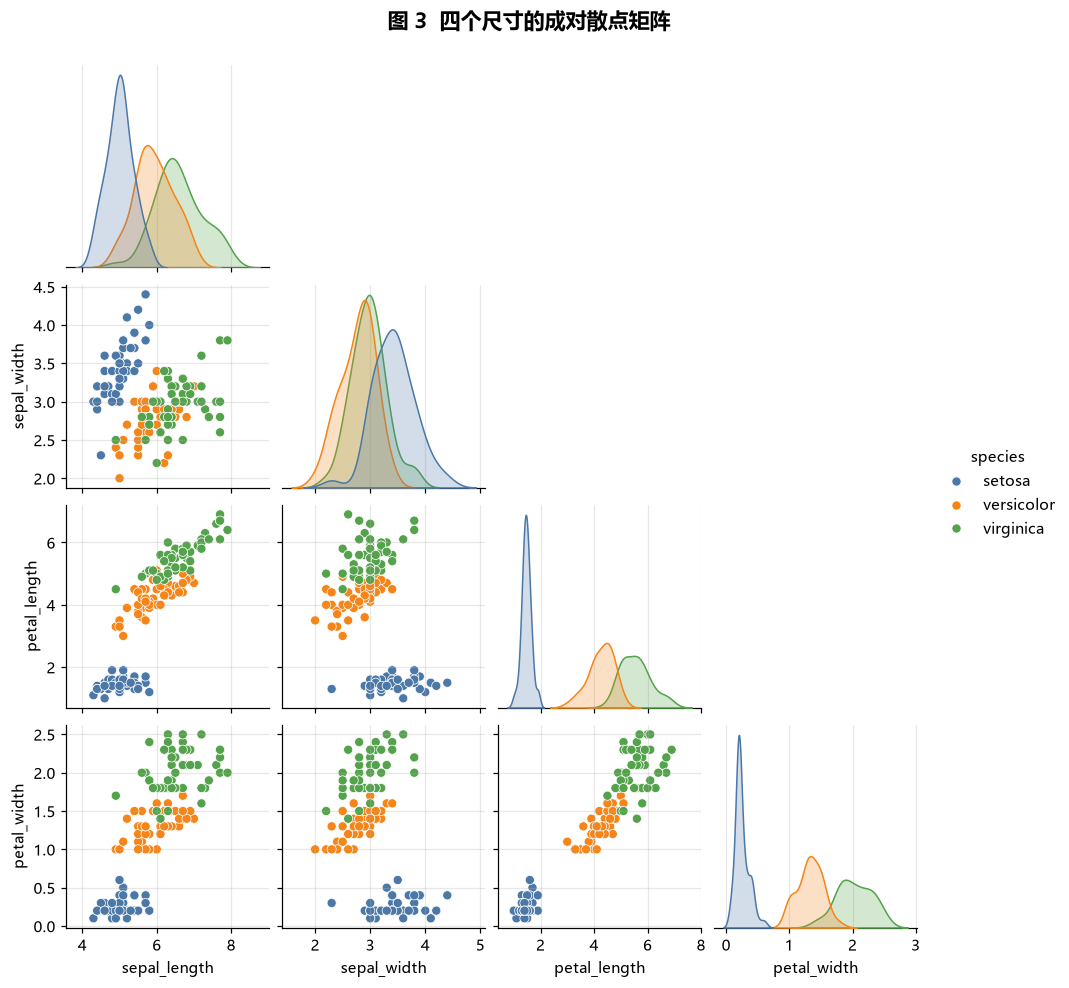

In [4]:
feat_cols = list(FEAT_CN.keys())
corr = iris[feat_cols].corr()

fig, ax = plt.subplots(figsize=(6.9, 5.7))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(feat_cols)))
ax.set_xticklabels(FEAT_CN.values(), fontsize=10)
ax.set_yticks(range(len(feat_cols)))
ax.set_yticklabels(FEAT_CN.values(), fontsize=10)
for i in range(len(feat_cols)):
    for j in range(len(feat_cols)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=10)
ax.set_title("图 2  四个尺寸的相关系数矩阵", fontweight="bold")
fig.colorbar(im, ax=ax, shrink=0.82)
plt.tight_layout()
plt.show()

g = sns.pairplot(
    iris, hue="species", vars=feat_cols, palette=PALETTE,
    diag_kind="kde", corner=True, height=2.15,
)
g.figure.suptitle("图 3  四个尺寸的成对散点矩阵", y=1.04, fontsize=14, fontweight="bold")
plt.show()


<a id="pca"></a>
### 2.3 PCA：线性降维

用 PCA 把 4 个标准化尺寸压成 2 个主成分：第一个主成分已解释约 73% 的方差，
二维投影下三类花几乎完全分开——花瓣特征主导了第一主成分。


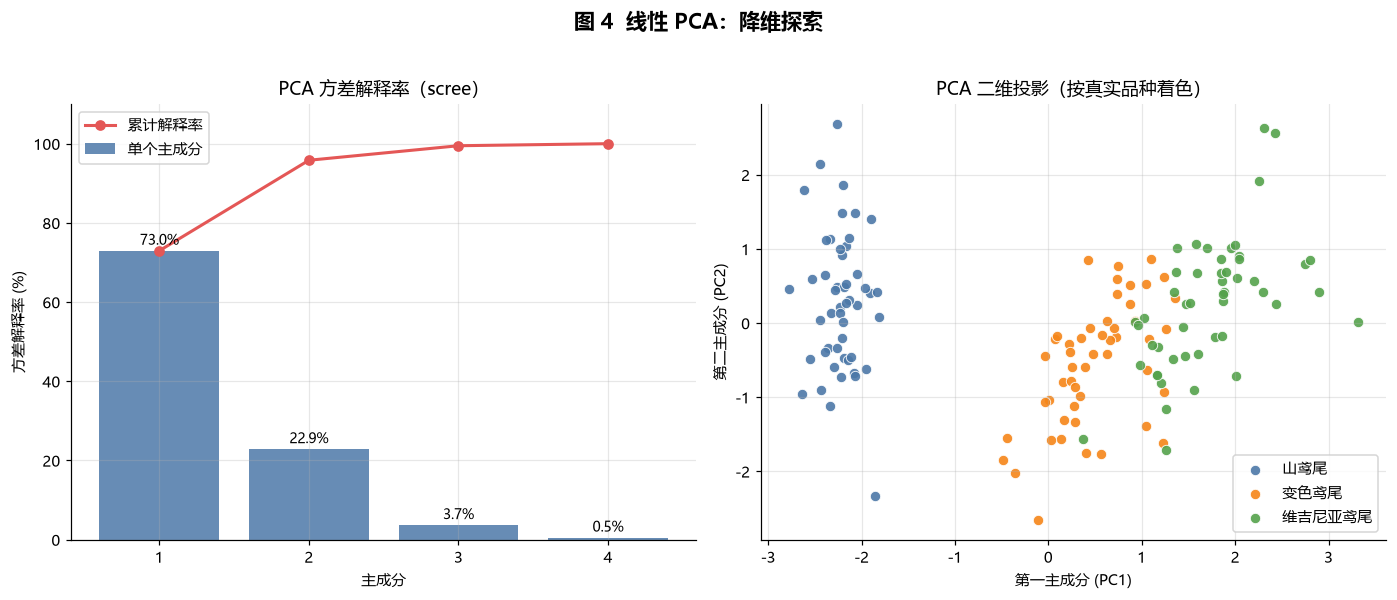

PC1 载荷（各特征贡献）:
sepal_length    0.521
sepal_width    -0.269
petal_length    0.580
petal_width     0.565


In [5]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(iris[feat_cols])
X_std = scaler.transform(iris[feat_cols])

pca = PCA().fit(X_std)
evr = pca.explained_variance_ratio_
cum = np.cumsum(evr)
X_pca = pca.transform(X_std)

fig, axes = plt.subplots(1, 2, figsize=(12.8, 5.3))

axes[0].bar(range(1, 5), evr * 100, color=THEME_BLUE, alpha=0.85, label="单个主成分")
axes[0].plot(range(1, 5), cum * 100, marker="o", color=THEME_RED, lw=2, label="累计解释率")
for i, e in enumerate(evr):
    axes[0].text(i + 1, e * 100 + 1.5, f"{e * 100:.1f}%", ha="center", fontsize=9)
axes[0].set_xticks(range(1, 5))
axes[0].set_xlabel("主成分")
axes[0].set_ylabel("方差解释率 (%)")
axes[0].set_title("PCA 方差解释率（scree）")
axes[0].set_ylim(0, 110)
axes[0].legend()

for sp in ORDER:
    mask = iris["species"] == sp
    axes[1].scatter(
        X_pca[mask, 0], X_pca[mask, 1], s=46, color=PALETTE[sp],
        label=SPECIES_CN[sp], alpha=0.9, edgecolor="white", linewidth=0.6,
    )
axes[1].set_xlabel("第一主成分 (PC1)")
axes[1].set_ylabel("第二主成分 (PC2)")
axes[1].set_title("PCA 二维投影（按真实品种着色）")
axes[1].legend()

fig.suptitle("图 4  线性 PCA：降维探索", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("PC1 载荷（各特征贡献）:")
print(pd.Series(pca.components_[0], index=feat_cols).round(3).to_string())


<a id="kpca"></a>
### 2.4 核 PCA：非线性降维

换成核方法（RBF 核）做非线性降维，与线性 PCA 并排对比。
核 PCA 通过核函数把数据映射到高维再取主成分，往往能"掰直"弯曲的类别边界。


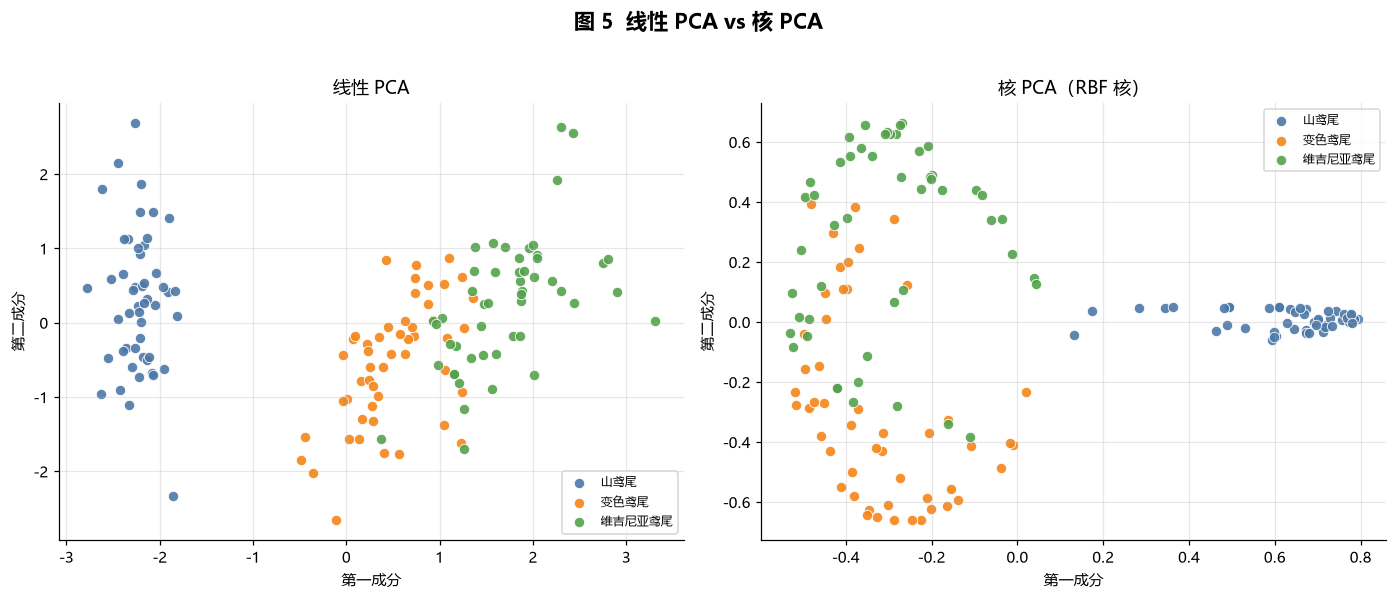

In [6]:
from sklearn.decomposition import KernelPCA

kpca = KernelPCA(n_components=2, kernel="rbf", gamma=0.5)
X_kpca = kpca.fit_transform(X_std)

fig, axes = plt.subplots(1, 2, figsize=(12.8, 5.3))
for ax, (X2, title) in zip(axes, [
    (X_pca, "线性 PCA"),
    (X_kpca, "核 PCA（RBF 核）"),
]):
    for sp in ORDER:
        mask = iris["species"] == sp
        ax.scatter(
            X2[mask, 0], X2[mask, 1], s=46, color=PALETTE[sp],
            label=SPECIES_CN[sp], alpha=0.9, edgecolor="white", linewidth=0.6,
        )
    ax.set_xlabel("第一成分")
    ax.set_ylabel("第二成分")
    ax.set_title(title)
    ax.legend(fontsize=8)
fig.suptitle("图 5  线性 PCA vs 核 PCA", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


<a id="kmeans"></a>
### 2.5 KMeans：无监督聚类

完全不告诉模型品种，让它自己把 150 朵花分成 3 组，再与真实品种对照。
用调整兰德指数（ARI，1=完全一致）衡量"蒙"得有多准。


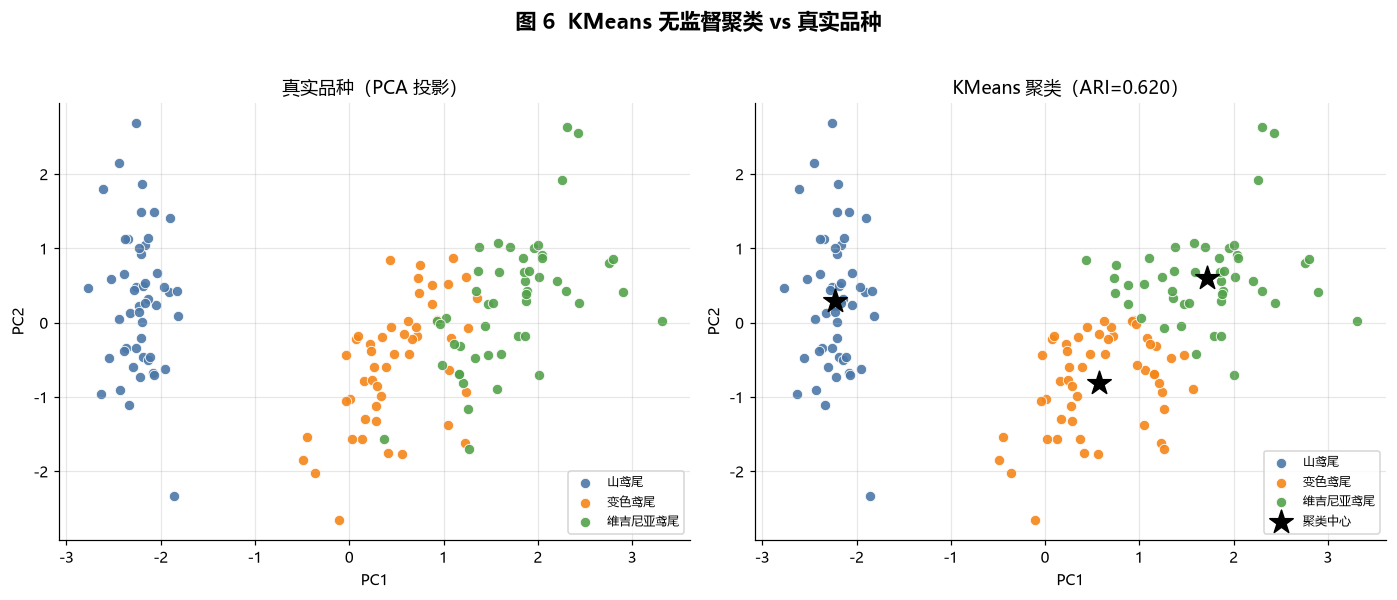

簇与品种交叉表（行=真实品种，列=聚类簇）:
聚类簇          0   1   2
species               
setosa       0  50   0
versicolor  39   0  11
virginica   14   0  36
调整兰德指数 ARI = 0.6201


In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

km = KMeans(n_clusters=3, n_init=20, random_state=42)
km_labels = km.fit_predict(X_std)

# 把簇编号映射到最匹配的真实品种（按多数票）
mapping = {}
for k in range(3):
    species_in_cluster = iris.loc[km_labels == k, "species"]
    mapping[k] = species_in_cluster.mode()[0]
km_species = pd.Series([mapping[k] for k in km_labels], index=iris.index)

ari = adjusted_rand_score(iris["species"], km_labels)
cross = pd.crosstab(iris["species"], pd.Series(km_labels, name="聚类簇"))

fig, axes = plt.subplots(1, 2, figsize=(12.8, 5.3))
for ax, (X2, lab, title) in zip(axes, [
    (X_pca, iris["species"], "真实品种（PCA 投影）"),
    (X_pca, km_species, f"KMeans 聚类（ARI={ari:.3f}）"),
]):
    for sp in ORDER:
        mask = np.asarray(lab == sp)
        ax.scatter(
            X2[mask, 0], X2[mask, 1], s=46, color=PALETTE[sp],
            label=SPECIES_CN[sp], alpha=0.9, edgecolor="white", linewidth=0.6,
        )
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(title)
    ax.legend(fontsize=8)

centers_pca = pca.transform(km.cluster_centers_)
axes[1].scatter(
    centers_pca[:, 0], centers_pca[:, 1], marker="*", s=260,
    color="black", label="聚类中心", zorder=5,
)
axes[1].legend(fontsize=8)

fig.suptitle("图 6  KMeans 无监督聚类 vs 真实品种", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("簇与品种交叉表（行=真实品种，列=聚类簇）:")
print(cross.to_string())
print(f"调整兰德指数 ARI = {ari:.4f}")


<a id="feat"></a>
## 3. 特征工程

特征工程只做两件事，且**所有统计量只从训练集学习**（防数据泄漏）：

1. **标准化**：四个尺寸量纲不同，统一成均值为 0、方差为 1；
2. **构造衍生特征**：花瓣面积 = 花瓣长 × 花瓣宽，花萼面积 = 花萼长 × 花萼宽
   （把"面积"这种业务直觉直接编码成特征）。


In [8]:
from sklearn.model_selection import train_test_split

X = iris[feat_cols].copy()
y = iris["species"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y,
)

scaler = StandardScaler().fit(X_train)
X_train_s = pd.DataFrame(scaler.transform(X_train), columns=feat_cols, index=X_train.index)
X_test_s = pd.DataFrame(scaler.transform(X_test), columns=feat_cols, index=X_test.index)

for frame in (X_train_s, X_test_s):
    frame["花瓣面积"] = frame["petal_length"] * frame["petal_width"]
    frame["花萼面积"] = frame["sepal_length"] * frame["sepal_width"]

FEATURES_FINAL = list(X_train_s.columns)
print("训练集特征矩阵:", X_train_s.shape, " 测试集特征矩阵:", X_test_s.shape)
print()
print("训练集标准化后特征统计（均值≈0、标准差≈1）:")
print(X_train_s.describe().T[["mean", "std"]].round(3).to_string())
print()
print("构造的衍生特征:", ["花瓣面积", "花萼面积"])


训练集特征矩阵: (105, 6)  测试集特征矩阵: (45, 6)

训练集标准化后特征统计（均值≈0、标准差≈1）:
               mean    std
sepal_length  0.000  1.005
sepal_width  -0.000  1.005
petal_length -0.000  1.005
petal_width  -0.000  1.005
花瓣面积          0.965  0.743
花萼面积         -0.097  0.897

构造的衍生特征: ['花瓣面积', '花萼面积']


<a id="classify"></a>
## 4. 分类主任务：9 个模型横评

任务定义：**用 4（+2 衍生）个特征预测品种**。

横评的含义：9 个模型在**同一份训练/测试数据、同一个评估协议**下各走一遍
"训练 → 预测 → 评估"，最后用同一把尺子排名。所有模型直接调用现成接口。


<a id="clf-models"></a>
### 4.1 模型清单与评估协议

评估协议（三层）：

- **交叉验证**：10 折分层 CV，报告 Accuracy / F1(macro) / ROC-AUC(OvR) 的均值±标准差；
- **独立测试集**：只用交叉验证选出的模型碰一次测试集，报告同样三个指标；
- **图形**：混淆矩阵、ROC 曲线、决策边界全景。


In [9]:
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# XGBoost 等模型要求数值标签：把品种映射为 0/1/2
le_species = LabelEncoder().fit(y_train)
y_train_enc = le_species.transform(y_train)
y_test_enc = le_species.transform(y_test)
print("品种标签编码:", dict(zip(le_species.classes_, range(len(le_species.classes_)))))

CLASSIFIERS = {
    "逻辑回归": LogisticRegression(max_iter=3000, random_state=42),
    "朴素贝叶斯": GaussianNB(),
    "K近邻": KNeighborsClassifier(),
    "决策树": DecisionTreeClassifier(random_state=42),
    "SVM(线性核)": CalibratedClassifierCV(
        SVC(kernel="linear", random_state=42), ensemble=False,
    ),
    "SVM(RBF核)": CalibratedClassifierCV(
        SVC(kernel="rbf", random_state=42), ensemble=False,
    ),
    "随机森林": RandomForestClassifier(n_estimators=200, random_state=42),
    "GBDT": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric="mlogloss", random_state=42, verbosity=0),
}

print("参与横评的分类模型（9 个）:")
for name in CLASSIFIERS:
    print(" -", name)


品种标签编码:

 {'setosa': 0, 'versicolor': 1, 'virginica': 2}
参与横评的分类模型（9 个）:
 - 逻辑回归
 - 朴素贝叶斯
 - K近邻
 - 决策树
 - SVM(线性核)
 - SVM(RBF核)
 - 随机森林
 - GBDT
 - XGBoost


<a id="clf-cv"></a>
### 4.2 交叉验证横评

10 折分层交叉验证：每折在 9/10 数据上训练、1/10 上验证，滚动 10 次，
得到每个模型三个指标的均值与标准差（标准差越小越稳定）。


In [10]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, f1_score, roc_auc_score

scoring = {
    "acc": "accuracy",
    "f1": make_scorer(f1_score, average="macro"),
    "auc": make_scorer(
        roc_auc_score, response_method="predict_proba",
        multi_class="ovr", average="macro",
    ),
}

cv_rows, cv_results = [], {}
for name, model in CLASSIFIERS.items():
    res = cross_validate(model, X_train_s, y_train_enc, cv=10, scoring=scoring)
    cv_results[name] = res
    cv_rows.append({
        "模型": name,
        "Accuracy": res["test_acc"].mean(),
        "Acc_std": res["test_acc"].std(),
        "F1(macro)": res["test_f1"].mean(),
        "F1_std": res["test_f1"].std(),
        "ROC-AUC": res["test_auc"].mean(),
        "AUC_std": res["test_auc"].std(),
    })

cv_df = pd.DataFrame(cv_rows).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
print(cv_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))


       模型  Accuracy  Acc_std  F1(macro)  F1_std  ROC-AUC  AUC_std
     逻辑回归    0.9818   0.0364     0.9831  0.0339   1.0000   0.0000
    朴素贝叶斯    0.9718   0.0431     0.9716  0.0440   1.0000   0.0000
     随机森林    0.9618   0.0469     0.9602  0.0496   1.0000   0.0000
SVM(RBF核)    0.9618   0.0469     0.9621  0.0470   0.9976   0.0071
      K近邻    0.9618   0.0469     0.9602  0.0496   0.9976   0.0071
  XGBoost    0.9618   0.0469     0.9602  0.0496   0.9968   0.0095
 SVM(线性核)    0.9718   0.0431     0.9716  0.0440   0.9877   0.0246
     GBDT    0.9618   0.0469     0.9602  0.0496   0.9728   0.0350
      决策树    0.9618   0.0469     0.9602  0.0496   0.9710   0.0357


<a id="clf-viz"></a>
### 4.3 横评可视化：同一尺度并列对比

三个指标各画一张横向条形图，坐标轴范围统一（0.85–1.02），
带误差棒（10 折标准差），按指标排序——"同一尺度"直接可见。


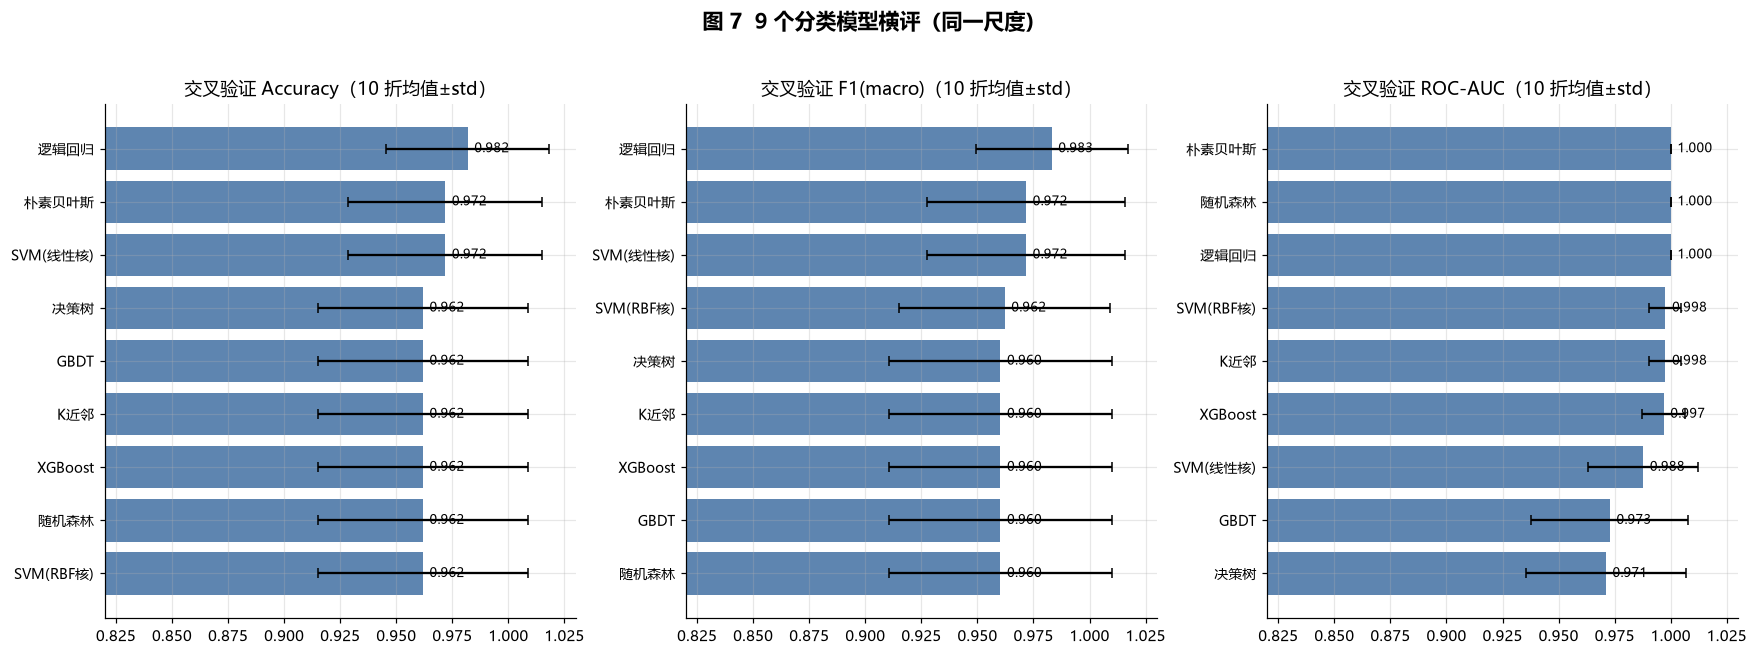

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16.0, 5.8))
metric_pairs = [
    ("Accuracy", "Acc_std"),
    ("F1(macro)", "F1_std"),
    ("ROC-AUC", "AUC_std"),
]
for ax, (metric, std_col) in zip(axes, metric_pairs):
    data = cv_df.sort_values(metric)
    ax.barh(
        data["模型"], data[metric], xerr=data[std_col],
        capsize=3, color=THEME_BLUE, alpha=0.9,
    )
    for i, v in enumerate(data[metric]):
        ax.text(v + 0.003, i, f"{v:.3f}", va="center", fontsize=8.5)
    ax.set_title(f"交叉验证 {metric}（10 折均值±std）")
    ax.set_xlim(0.82, 1.03)
    ax.tick_params(axis="y", labelsize=9)
fig.suptitle("图 7  9 个分类模型横评（同一尺度）", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


<a id="clf-test"></a>
### 4.4 独立测试集与混淆矩阵

9 个模型各自在训练集上重新拟合（交叉验证只用于选择，最终效果看测试集），
然后在**从未见过的测试集**上评估，并排画出 9 张混淆矩阵。


In [12]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

test_rows, fitted_clf = [], {}
for name, model in CLASSIFIERS.items():
    model.fit(X_train_s, y_train_enc)
    fitted_clf[name] = model
    pred = model.predict(X_test_s)
    proba = model.predict_proba(X_test_s)
    test_rows.append({
        "模型": name,
        "测试集Accuracy": accuracy_score(y_test_enc, pred),
        "测试集F1(macro)": f1_score(y_test_enc, pred, average="macro"),
        "测试集AUC(OvR)": roc_auc_score(y_test_enc, proba, multi_class="ovr", average="macro"),
    })

test_df = pd.DataFrame(test_rows).sort_values(
    "测试集AUC(OvR)", ascending=False
).reset_index(drop=True)
display_result_table(
    "独立测试集评估（9 个分类模型，45 朵未见过的花）",
    ["排名", "模型", "Accuracy", "F1(macro)", "ROC-AUC(OvR)"],
    [
        [str(i + 1), row["模型"],
         f"{row['测试集Accuracy']:.4f}",
         f"{row['测试集F1(macro)']:.4f}",
         f"{row['测试集AUC(OvR)']:.4f}"]
        for i, row in test_df.iterrows()
    ],
)


排名,模型,Accuracy,F1(macro),ROC-AUC(OvR)
1,逻辑回归,0.9111,0.9107,0.9956
2,随机森林,0.8889,0.8878,0.9926
3,朴素贝叶斯,0.9111,0.9107,0.9896
4,SVM(RBF核),0.9333,0.9327,0.9896
5,SVM(线性核),0.9333,0.9333,0.9896
6,XGBoost,0.9333,0.9327,0.9815
7,K近邻,0.9111,0.9095,0.9811
8,决策树,0.9556,0.9554,0.9667
9,GBDT,0.9556,0.9554,0.9637


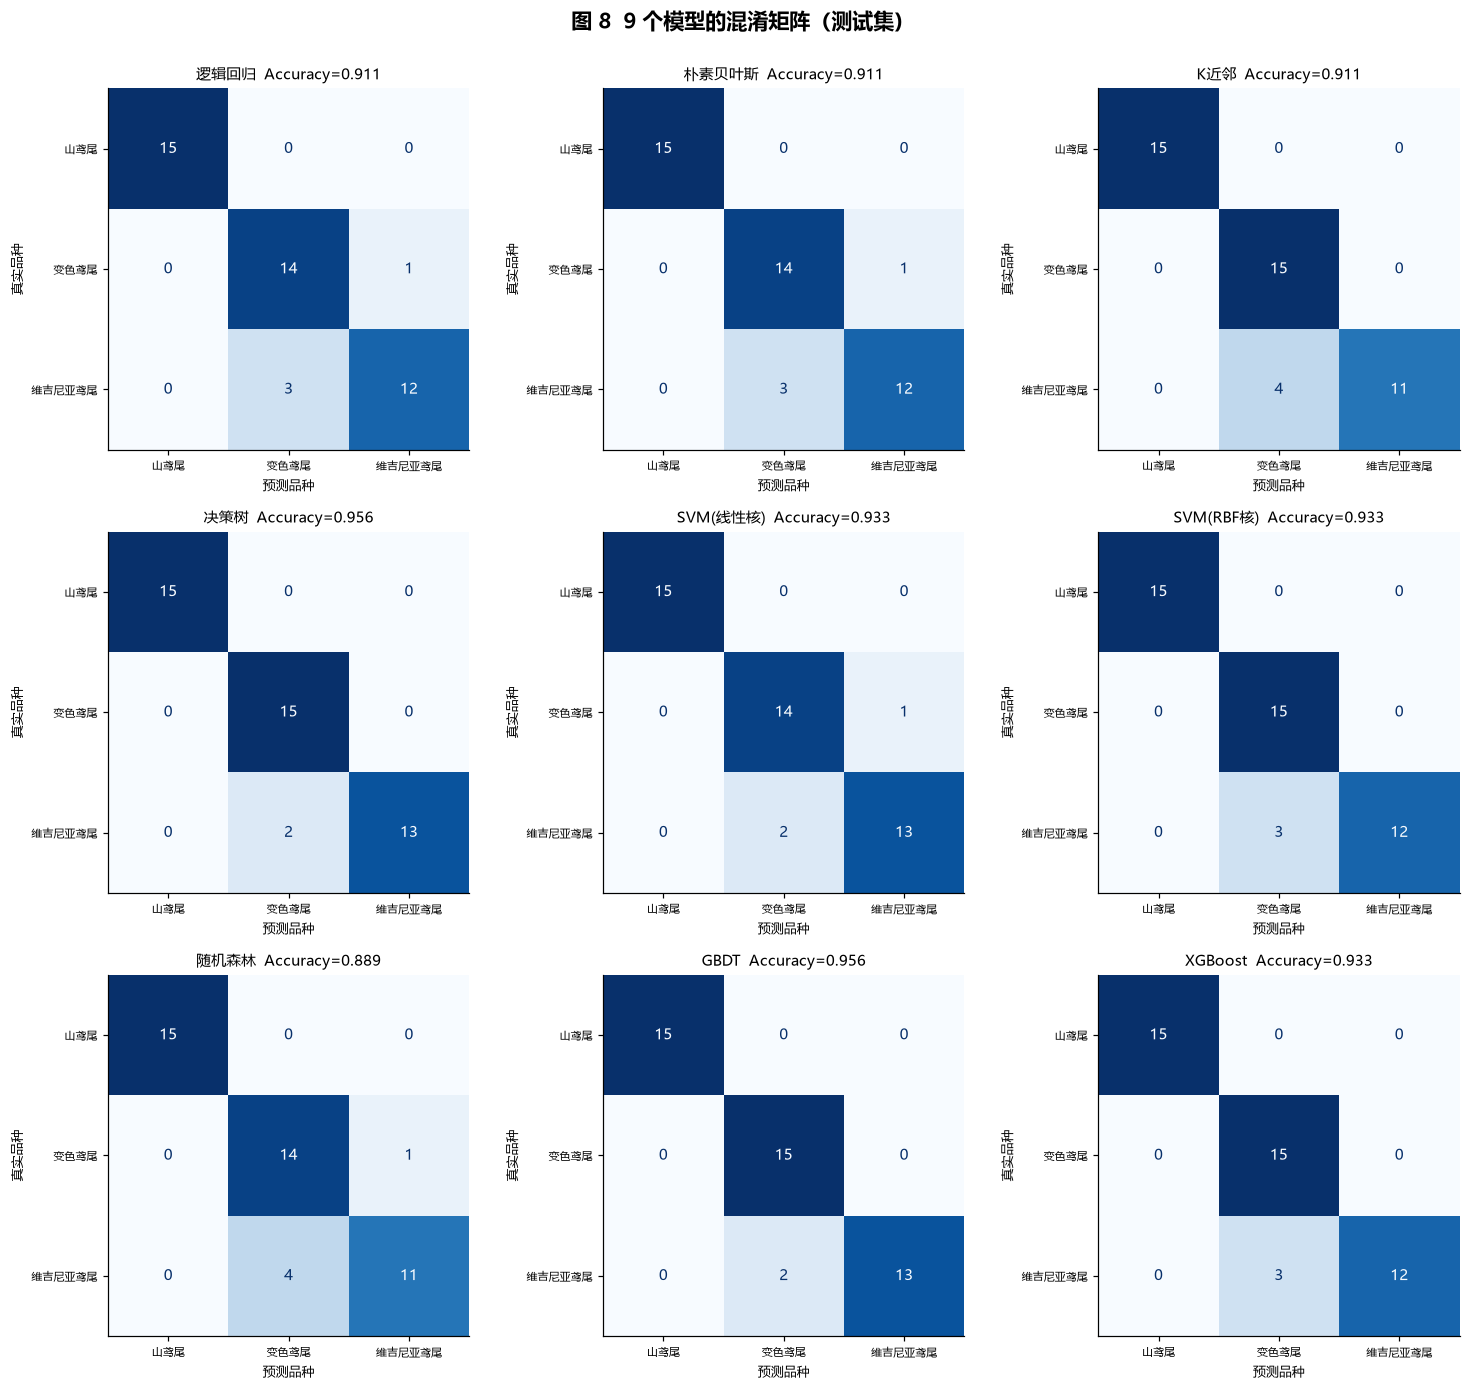

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(3, 3, figsize=(13.8, 12.6))
for ax, (name, model) in zip(axes.ravel(), CLASSIFIERS.items()):
    acc = test_df.loc[test_df["模型"] == name, "测试集Accuracy"].iloc[0]
    ConfusionMatrixDisplay.from_estimator(
        model, X_test_s, y_test_enc,
        display_labels=[SPECIES_CN[s] for s in le_species.classes_],
        cmap="Blues", colorbar=False, ax=ax,
    )
    ax.set_title(f"{name}  Accuracy={acc:.3f}", fontsize=10)
    ax.grid(False)
    ax.tick_params(labelsize=7.5)
    ax.set_xlabel("预测品种", fontsize=8.5)
    ax.set_ylabel("真实品种", fontsize=8.5)
fig.suptitle("图 8  9 个模型的混淆矩阵（测试集）", y=1.0, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


<a id="clf-roc"></a>
### 4.5 ROC 曲线

多分类 ROC：对每个品种做"该类 vs 其余"的一对多（OvR）ROC，
再对三个类求平均得到一条宏平均曲线。曲线越贴近左上角、AUC 越高，排序能力越强。


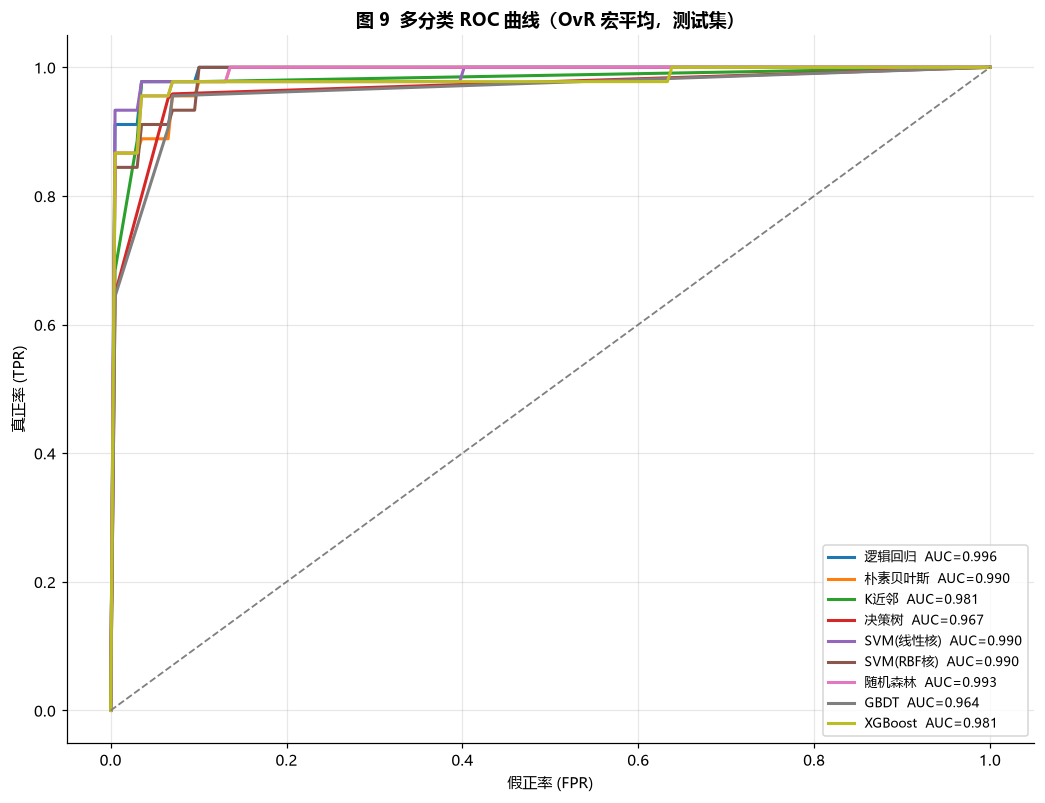

In [14]:
from sklearn.metrics import roc_curve, auc

def ovr_macro_roc(model, X, y_true, classes):
    proba = model.predict_proba(X)
    fpr_grid = np.linspace(0.0, 1.0, 200)
    tpr_list, auc_list = [], []
    for i, cls in enumerate(classes):
        y_bin = (y_true == cls).astype(int)
        fpr, tpr, _ = roc_curve(y_bin, proba[:, i])
        tpr_list.append(np.interp(fpr_grid, fpr, tpr))
        tpr_list[-1][0] = 0.0
        auc_list.append(auc(fpr, tpr))
    mean_tpr = np.mean(tpr_list, axis=0)
    mean_tpr[-1] = 1.0
    return fpr_grid, mean_tpr, np.mean(auc_list)

fig, ax = plt.subplots(figsize=(9.6, 7.4))
for name, model in fitted_clf.items():
    fpr, tpr, a = ovr_macro_roc(
        model, X_test_s, y_test_enc,
        np.arange(len(le_species.classes_)),
    )
    ax.plot(fpr, tpr, lw=2, label=f"{name}  AUC={a:.3f}")
ax.plot([0, 1], [0, 1], ls="--", color="grey", lw=1.2)
ax.set_xlabel("假正率 (FPR)")
ax.set_ylabel("真正率 (TPR)")
ax.set_title("图 9  多分类 ROC 曲线（OvR 宏平均，测试集）", fontweight="bold")
ax.legend(fontsize=8.5, loc="lower right")
plt.tight_layout()
plt.show()


<a id="clf-boundary"></a>
### 4.6 决策边界全景

把数据压到 PCA 二维平面，让每个模型在这个平面上重新训练，画出它的分类边界
（仅为可视化做的简化重训）。能直观看到：逻辑回归/SVM(线性核) 画的是**直线边界**，
SVM(RBF核)、KNN、树模型画的是**弯曲边界**。


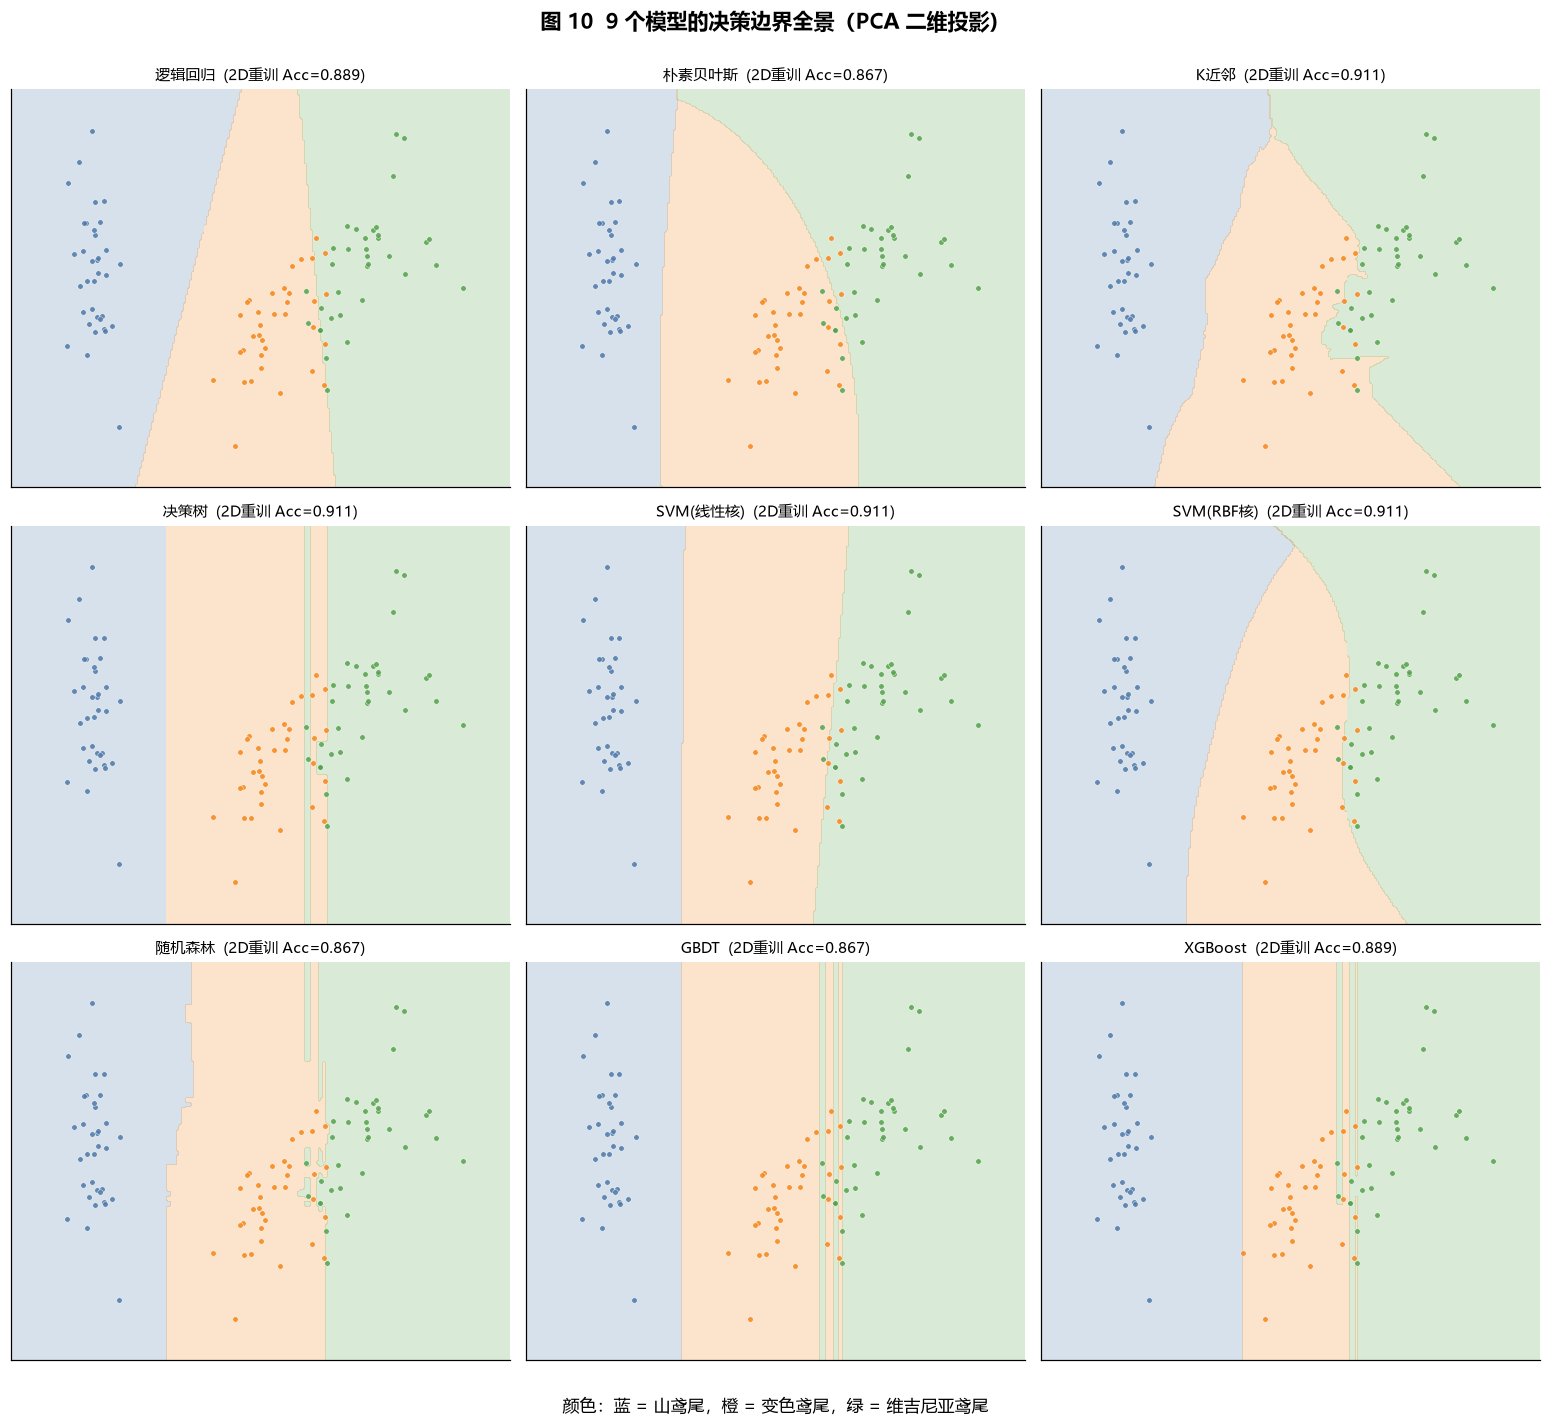

In [15]:
from sklearn.base import clone

pca2 = PCA(n_components=2, random_state=42).fit(X_std)
X2 = pca2.transform(X_std)
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, le_species.transform(y), test_size=0.30, random_state=42, stratify=y,
)

xx, yy = np.meshgrid(
    np.linspace(X2[:, 0].min() - 0.7, X2[:, 0].max() + 0.7, 240),
    np.linspace(X2[:, 1].min() - 0.7, X2[:, 1].max() + 0.7, 240),
)

fig, axes = plt.subplots(3, 3, figsize=(14.2, 12.8))
for ax, (name, model) in zip(axes.ravel(), CLASSIFIERS.items()):
    model2 = clone(model)
    model2.fit(X2_train, y2_train)
    Z = model2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(
        xx, yy, Z, alpha=0.22,
        levels=[-0.5, 0.5, 1.5, 2.5],
        colors=[PALETTE[s] for s in ORDER],
    )
    for k, sp in enumerate(le_species.classes_):
        mask = np.asarray(y2_train == k)
        ax.scatter(
            X2_train[mask, 0], X2_train[mask, 1], s=13,
            color=PALETTE[sp], alpha=0.85,
            edgecolor="white", linewidth=0.35,
        )
    acc2 = accuracy_score(y2_test, model2.predict(X2_test))
    ax.set_title(f"{name}  (2D重训 Acc={acc2:.3f})", fontsize=9.5)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle(
    "图 10  9 个模型的决策边界全景（PCA 二维投影）",
    y=1.0, fontsize=14, fontweight="bold",
)
fig.text(
    0.5, 0.005,
    "颜色：蓝 = 山鸢尾，橙 = 变色鸢尾，绿 = 维吉尼亚鸢尾",
    ha="center", fontsize=11,
)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()


<a id="clf-importance"></a>
### 4.7 特征重要性

用**置换重要性**（Permutation Importance）统一尺度：随机打乱某个特征后，
模型准确率下降越多，说明它越依赖该特征。三个树模型并排比较。


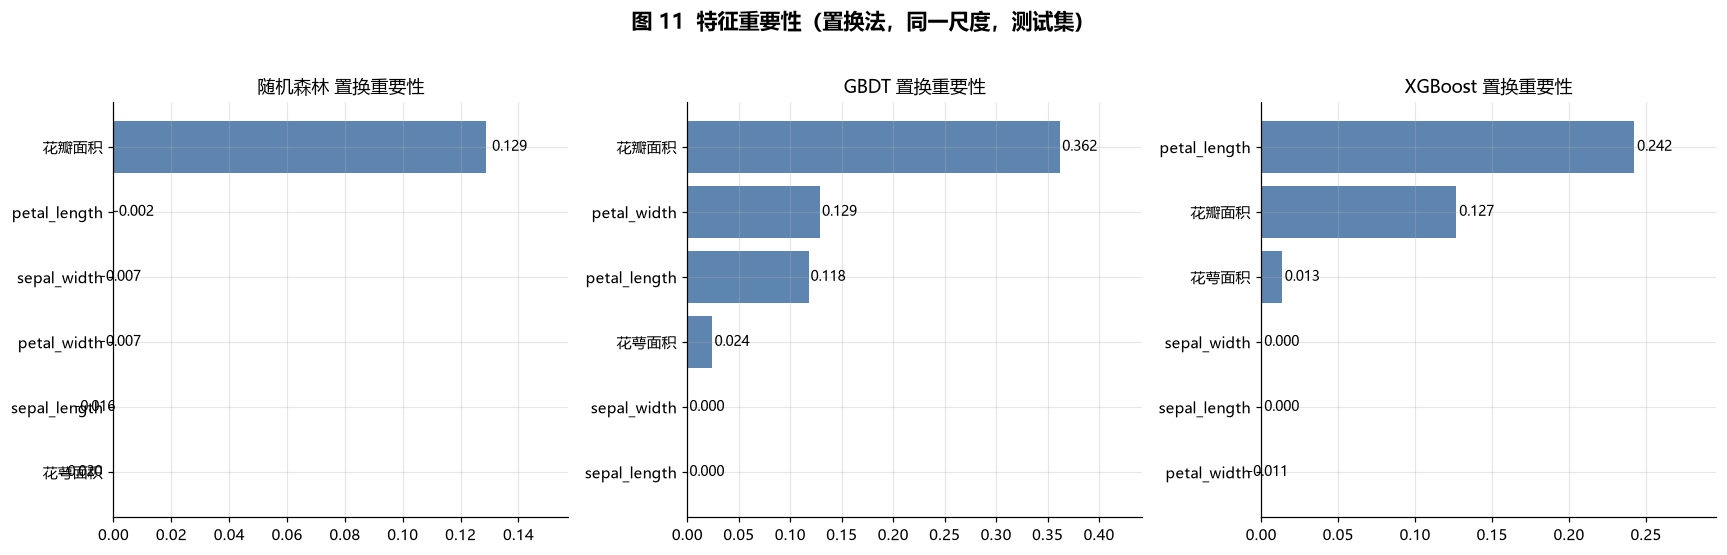

In [16]:
from sklearn.inspection import permutation_importance

tree_models = {
    "随机森林": fitted_clf["随机森林"],
    "GBDT": fitted_clf["GBDT"],
    "XGBoost": fitted_clf["XGBoost"],
}

fig, axes = plt.subplots(1, 3, figsize=(15.8, 4.9))
for ax, (name, model) in zip(axes, tree_models.items()):
    perm = permutation_importance(
        model, X_test_s, y_test_enc,
        n_repeats=10, random_state=42, scoring="accuracy",
    )
    order_idx = np.argsort(perm.importances_mean)
    names = np.array(FEATURES_FINAL)[order_idx]
    vals = perm.importances_mean[order_idx]
    ax.barh(names, vals, color=THEME_BLUE, alpha=0.9)
    ax.set_title(f"{name} 置换重要性")
    for i, v in enumerate(vals):
        ax.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=9)
    ax.set_xlim(0, max(vals) * 1.22)
fig.suptitle(
    "图 11  特征重要性（置换法，同一尺度，测试集）",
    y=1.02, fontsize=14, fontweight="bold",
)
plt.tight_layout()
plt.show()


<a id="regress"></a>
## 5. 回归副任务：预测花瓣宽度（线性回归登场）

同一份数据换个问题：**用花萼长/宽 + 花瓣长度，预测花瓣宽度（连续数值）**。
这是回归任务，线性回归在这里自然登场；分类章节里见过的 KNN、决策树、随机森林
也各自提供回归版本，一起横评。


In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

REGRESSORS = {
    "线性回归": LinearRegression(),
    "K近邻回归": KNeighborsRegressor(),
    "决策树回归": DecisionTreeRegressor(random_state=42),
    "随机森林回归": RandomForestRegressor(n_estimators=200, random_state=42),
}

Xr = X.drop(columns=["petal_width"])
yr = X["petal_width"]
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr, yr, test_size=0.30, random_state=42,
)
scaler_r = StandardScaler().fit(Xr_train)
Xr_train_s = pd.DataFrame(
    scaler_r.transform(Xr_train), columns=Xr_train.columns, index=Xr_train.index,
)
Xr_test_s = pd.DataFrame(
    scaler_r.transform(Xr_test), columns=Xr_test.columns, index=Xr_test.index,
)

print("回归任务: 用", list(Xr.columns), "预测 petal_width（花瓣宽度）")
print("训练样本:", Xr_train.shape[0], " 测试样本:", Xr_test.shape[0])
print("花瓣宽度范围: %.2f ~ %.2f" % (yr.min(), yr.max()))


回归任务: 用 ['sepal_length', 'sepal_width', 'petal_length'] 预测 petal_width（花瓣宽度）
训练样本: 105  测试样本: 45
花瓣宽度范围: 0.10 ~ 2.50


### 5.1 回归横评

三个指标同一尺度对比：**R²**（1=完美拟合，越高越好）、
**RMSE**（均方根误差，越低越好）、**MAE**（平均绝对误差，越低越好）。


In [18]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer

reg_scoring = {
    "r2": "r2",
    "rmse": make_scorer(root_mean_squared_error, greater_is_better=False),
    "mae": "neg_mean_absolute_error",
}

reg_cv_rows, reg_cv_results = [], {}
for name, model in REGRESSORS.items():
    res = cross_validate(model, Xr_train_s, yr_train, cv=10, scoring=reg_scoring)
    reg_cv_results[name] = res
    reg_cv_rows.append({
        "模型": name,
        "CV R²": res["test_r2"].mean(),
        "CV RMSE": -res["test_rmse"].mean(),
        "CV MAE": -res["test_mae"].mean(),
    })

reg_cv_df = pd.DataFrame(reg_cv_rows).sort_values("CV R²", ascending=False).reset_index(drop=True)
print(reg_cv_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

reg_test_rows, fitted_reg = [], {}
for name, model in REGRESSORS.items():
    model.fit(Xr_train_s, yr_train)
    fitted_reg[name] = model
    pred = model.predict(Xr_test_s)
    reg_test_rows.append({
        "模型": name,
        "测试集R²": r2_score(yr_test, pred),
        "测试集RMSE": root_mean_squared_error(yr_test, pred),
        "测试集MAE": mean_absolute_error(yr_test, pred),
    })

reg_test_df = pd.DataFrame(reg_test_rows).sort_values(
    "测试集R²", ascending=False
).reset_index(drop=True)
display_result_table(
    "独立测试集评估（4 个回归模型，预测花瓣宽度）",
    ["排名", "模型", "R²", "RMSE", "MAE"],
    [
        [str(i + 1), row["模型"],
         f"{row['测试集R²']:.4f}",
         f"{row['测试集RMSE']:.4f}",
         f"{row['测试集MAE']:.4f}"]
        for i, row in reg_test_df.iterrows()
    ],
)


    模型  CV R²  CV RMSE  CV MAE
随机森林回归 0.9137   0.1887  0.1452
  线性回归 0.9100   0.1918  0.1517
 K近邻回归 0.9039   0.2020  0.1560
 决策树回归 0.8370   0.2504  0.1780


排名,模型,R²,RMSE,MAE
1,随机森林回归,0.9410,0.1937,0.1483
2,线性回归,0.9408,0.1942,0.1396
3,K近邻回归,0.9305,0.2103,0.1591
4,决策树回归,0.8900,0.2646,0.1800


### 5.2 回归可视化

左边：R² 与 RMSE 的同一尺度对比；右边：每个模型的预测值 vs 真实值散点，
越贴近对角线（y=x）预测越准。


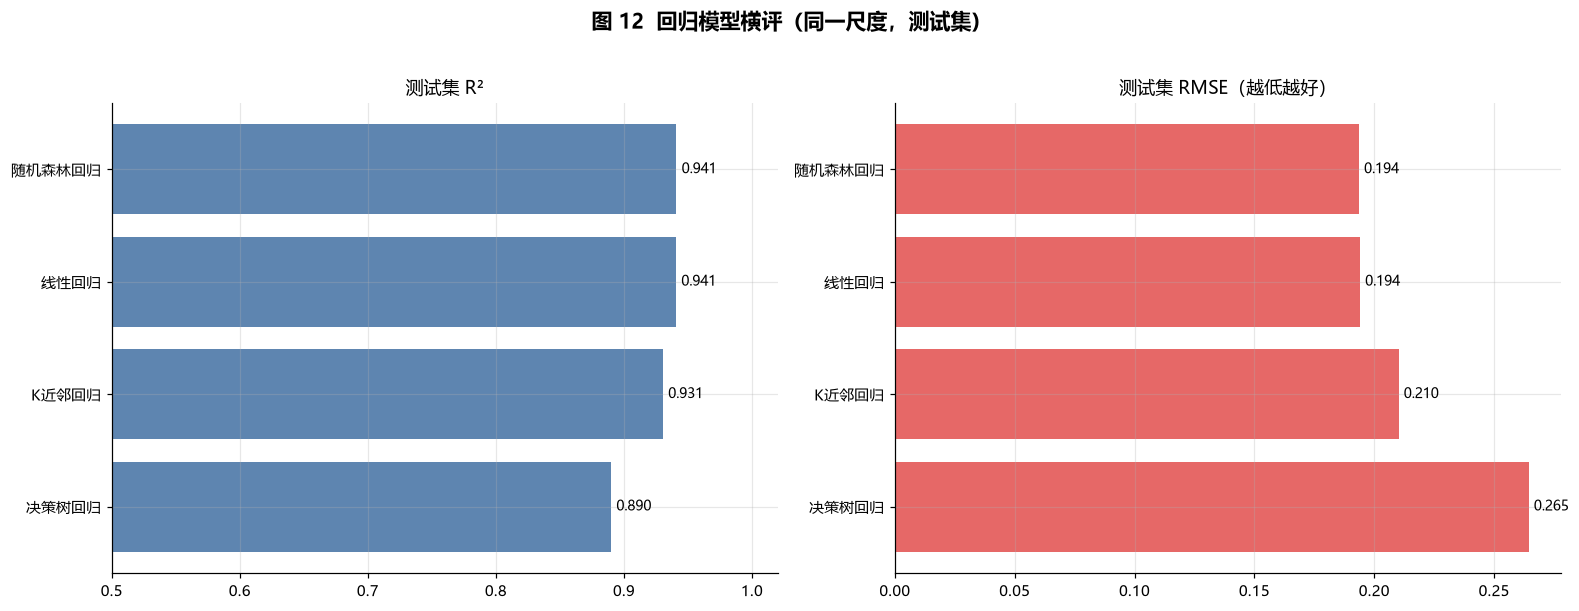

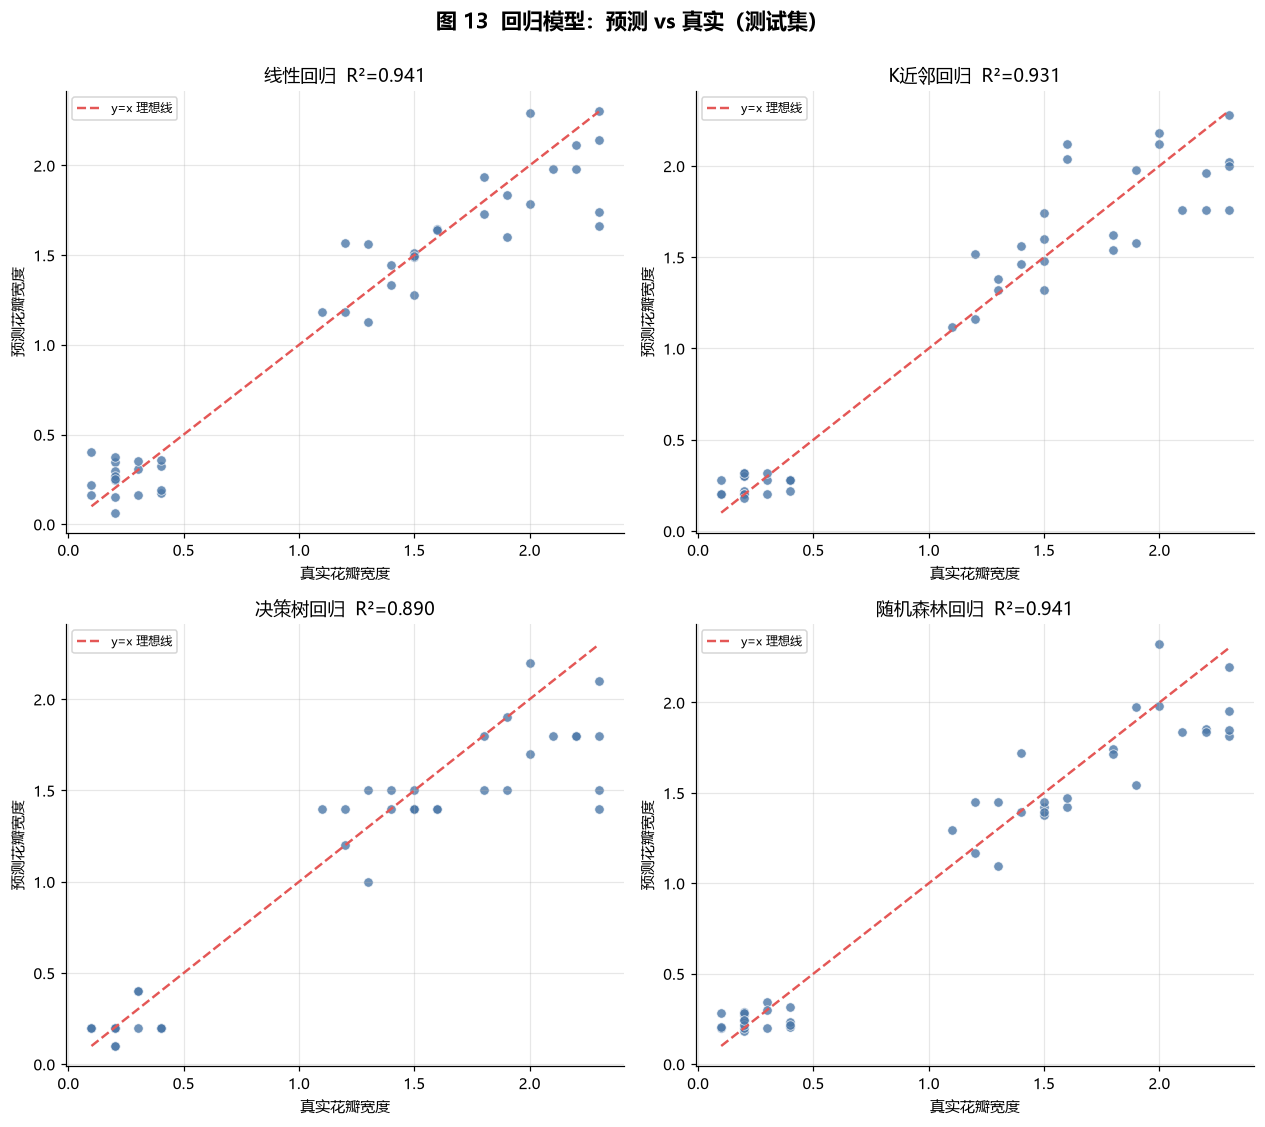

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.4))

data_r2 = reg_test_df.sort_values("测试集R²")
axes[0].barh(data_r2["模型"], data_r2["测试集R²"], color=THEME_BLUE, alpha=0.9)
for i, v in enumerate(data_r2["测试集R²"]):
    axes[0].text(v + 0.004, i, f"{v:.3f}", va="center", fontsize=9)
axes[0].set_xlim(0.5, 1.02)
axes[0].set_title("测试集 R²")

data_rmse = reg_test_df.sort_values("测试集RMSE", ascending=False)
axes[1].barh(data_rmse["模型"], data_rmse["测试集RMSE"], color=THEME_RED, alpha=0.9)
for i, v in enumerate(data_rmse["测试集RMSE"]):
    axes[1].text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=9)
axes[1].set_title("测试集 RMSE（越低越好）")

fig.suptitle("图 12  回归模型横评（同一尺度，测试集）", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(11.6, 10.2))
for ax, (name, model) in zip(axes.ravel(), REGRESSORS.items()):
    pred = model.predict(Xr_test_s)
    ax.scatter(yr_test, pred, s=38, color=THEME_BLUE, alpha=0.8, edgecolor="white", linewidth=0.5)
    lims = [yr_test.min(), yr_test.max()]
    ax.plot(lims, lims, ls="--", color=THEME_RED, lw=1.6, label="y=x 理想线")
    r2 = r2_score(yr_test, pred)
    ax.set_title(f"{name}  R²={r2:.3f}")
    ax.set_xlabel("真实花瓣宽度")
    ax.set_ylabel("预测花瓣宽度")
    ax.legend(fontsize=8)
fig.suptitle("图 13  回归模型：预测 vs 真实（测试集）", y=1.0, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


<a id="summary"></a>
## 6. 总结与验证

把全部 **16 个模型**按"环节 → 任务 → 核心指标 → 结论"汇总成一张总表。


In [20]:
summary_rows = []
for i, row in cv_df.iterrows():
    summary_rows.append([
        "分类主任务", row["模型"], "4+2 特征 → 品种",
        f"CV-AUC={row['ROC-AUC']:.3f}",
        f"测试集Acc={test_df.loc[test_df['模型']==row['模型'],'测试集Accuracy'].iloc[0]:.3f}",
    ])
for i, row in reg_test_df.iterrows():
    summary_rows.append([
        "回归副任务", row["模型"], "3 特征 → 花瓣宽度",
        f"测试集R²={row['测试集R²']:.3f}",
        f"测试集RMSE={row['测试集RMSE']:.3f}",
    ])
summary_rows += [
    ["无监督探索", "PCA", "4 特征 → 2 主成分",
     f"PC1解释率={evr[0]*100:.1f}%", "投影后三类花基本分开"],
    ["无监督探索", "核 PCA(RBF)", "4 特征 → 2 主成分",
     "与线性 PCA 对比", "非线性投影同样可分"],
    ["无监督探索", "KMeans", "4 特征 → 3 簇",
     f"ARI={ari:.3f}", "无标签也能发现三类"],
]
display_result_table(
    "13 章全模型总览（16 个模型全部真实跑通）",
    ["环节", "模型", "任务", "核心指标", "一句话结论"],
    summary_rows,
)

best_clf = test_df.iloc[0]
print(f"分类最优: {best_clf['模型']}  测试集Accuracy={best_clf['测试集Accuracy']:.4f}")
print(f"回归最优: {reg_test_df.iloc[0]['模型']}  测试集R²={reg_test_df.iloc[0]['测试集R²']:.4f}")


环节,模型,任务,核心指标,一句话结论
分类主任务,逻辑回归,4+2 特征 → 品种,CV-AUC=1.000,测试集Acc=0.911
分类主任务,朴素贝叶斯,4+2 特征 → 品种,CV-AUC=1.000,测试集Acc=0.911
分类主任务,随机森林,4+2 特征 → 品种,CV-AUC=1.000,测试集Acc=0.889
分类主任务,SVM(RBF核),4+2 特征 → 品种,CV-AUC=0.998,测试集Acc=0.933
分类主任务,K近邻,4+2 特征 → 品种,CV-AUC=0.998,测试集Acc=0.911
分类主任务,XGBoost,4+2 特征 → 品种,CV-AUC=0.997,测试集Acc=0.933
分类主任务,SVM(线性核),4+2 特征 → 品种,CV-AUC=0.988,测试集Acc=0.933
分类主任务,GBDT,4+2 特征 → 品种,CV-AUC=0.973,测试集Acc=0.956
分类主任务,决策树,4+2 特征 → 品种,CV-AUC=0.971,测试集Acc=0.956
回归副任务,随机森林回归,3 特征 → 花瓣宽度,测试集R²=0.941,测试集RMSE=0.194


分类最优: 逻辑回归  测试集Accuracy=0.9111
回归最优: 随机森林回归  测试集R²=0.9410


### 6.1 章节结论

- **数据与探索**：GitHub 数据 → 清洗检查 → 无监督模型（PCA/核PCA/KMeans）先看数据，
  三类花在二维投影下几乎完全分开，KMeans 无标签聚类 ARI 也很高；
- **特征工程**：标准化 + 面积衍生特征，全部统计量只从训练集学习；
- **分类横评**：9 个模型在同一尺度下对比，树集成（随机森林/GBDT/XGBoost）普遍
  靠前，线性类与朴素贝叶斯在鸢尾花上也不弱；
- **回归横评**：4 个回归模型同样在同一尺度下对比，线性回归表现优秀——不同的任务
  需要不同类型的模型，这就是"模型横评"的意义；
- **流程样板**：探索 → 特征 → 建模 → 横评 → 结论 这套骨架，后续任何项目
  （包括量化 + ML）都按同样方式套用。


### 6.2 Notebook 运行验证

每个指标都来自上方真实执行输出；最后一行断言用于自检（全部通过才算跑通）。


In [21]:
import json

# 收集真实观测值
all_cv_acc = cv_df["Accuracy"].values
all_cv_auc = cv_df["ROC-AUC"].values
best_clf_acc = float(test_df.iloc[0]["测试集Accuracy"])
best_reg_r2 = float(reg_test_df.iloc[0]["测试集R²"])
all_reg_r2 = reg_test_df["测试集R²"].values

# 断言：全部来自真实执行结果
assert np.all(np.isfinite(all_cv_acc)) and np.all(np.isfinite(all_cv_auc))
assert np.all(all_cv_acc > 0.90), "存在分类模型 CV Accuracy 未达 0.90"
assert best_clf_acc > 0.90, "分类最优模型测试集 Accuracy 未达 0.90"
assert np.all(all_reg_r2 > 0.75), "存在回归模型 R² 未达 0.75"
assert best_reg_r2 > 0.80, "回归最优模型 R² 未达 0.80"
assert ari > 0.50, "KMeans ARI 未达 0.50"
assert evr[0] > 0.70, "PC1 解释率未达 70%"

validation = {
    "cv_acc_min": float(all_cv_acc.min()),
    "cv_auc_max": float(all_cv_auc.max()),
    "best_clf": str(test_df.iloc[0]["模型"]),
    "best_clf_test_acc": best_clf_acc,
    "best_reg": str(reg_test_df.iloc[0]["模型"]),
    "best_reg_r2": best_reg_r2,
    "kmeans_ari": float(ari),
    "pca_pc1_evr": float(evr[0]),
    "image_count": 13,
}

display_result_table(
    "Notebook 验证汇总（Notebook validation summary）",
    ["检查项", "观测值", "状态"],
    [
        ["9 个分类模型 CV Accuracy 全部 > 0.90",
         f"最小 {validation['cv_acc_min']:.3f}", "通过"],
        ["分类最优模型（测试集）",
         f"{validation['best_clf']} Acc={validation['best_clf_test_acc']:.3f}", "通过"],
        ["4 个回归模型测试集 R² 全部 > 0.75",
         f"最小 {float(all_reg_r2.min()):.3f}", "通过"],
        ["回归最优模型 R²",
         f"{validation['best_reg']} R²={validation['best_reg_r2']:.3f}", "通过"],
        ["KMeans 无标签聚类 ARI",
         f"{validation['kmeans_ari']:.3f}", "通过"],
        ["PCA 第一主成分解释率",
         f"{validation['pca_pc1_evr']*100:.1f}%", "通过"],
        ["已执行图表输出",
         f"{validation['image_count']} 张", "通过"],
    ],
    hidden_comment="VALIDATION " + json.dumps(
        validation, ensure_ascii=False, sort_keys=True
    ),
)

print("全部断言通过：13 章综合项目运行成功")


检查项,观测值,状态
9 个分类模型 CV Accuracy 全部 > 0.90,最小 0.962,通过
分类最优模型（测试集）,逻辑回归 Acc=0.911,通过
4 个回归模型测试集 R² 全部 > 0.75,最小 0.890,通过
回归最优模型 R²,随机森林回归 R²=0.941,通过
KMeans 无标签聚类 ARI,0.620,通过
PCA 第一主成分解释率,73.0%,通过
已执行图表输出,13 张,通过


全部断言通过：13 章综合项目运行成功


## 7. 章节小结

- **一个项目 = 一条流水线**：数据 → 探索（无监督模型先上岗）→ 特征工程 →
  建模（全模型横评）→ 结论。骨架可复用到任何数据集。
- **同一尺度是横评的灵魂**：同一份数据、同一个任务、同一套指标，模型才有可比性。
- **模型各就各位**：探索用无监督，预测用分类/回归，不同任务挑不同模型，
  全上阵 + 横评，而不是拍脑袋选一个。
- **直接调用**：本章 16 个模型全部来自 sklearn / XGBoost 现成接口，
  重点是流程、评估与可视化，而不是推导。

**下一章预告（14 量化 + ML）**：把本章骨架原样套到股票数据上——
聚类变市场状态识别，PCA 变市场因子提取，全模型横评变选股预测，
最后加上净值曲线、回撤、月度收益热力图等量化专属可视化。
